In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. SETUP PARAMETERS
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 20
TRAIN_DIR = '/kaggle/input/datasets/lexset/synthetic-asl-alphabet/Train_Alphabet'
TEST_DIR = '/kaggle/input/datasets/lexset/synthetic-asl-alphabet/Test_Alphabet'

# 2. DATA AUGMENTATION & LOADING (To tackle Overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2  # Create a validation set from training data
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

2026-05-05 18:48:23.795169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778006904.190312      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778006904.298846      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778006905.269114      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778006905.269151      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778006905.269154      57 computation_placer.cc:177] computation placer alr

Found 19440 images belonging to 27 classes.
Found 4860 images belonging to 27 classes.
Found 2700 images belonging to 27 classes.


Number of classes  : 27
Classes            : ['A', 'B', 'Blank', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Total train images : 24300
Total test images  : 2700
Image size         : 64x64


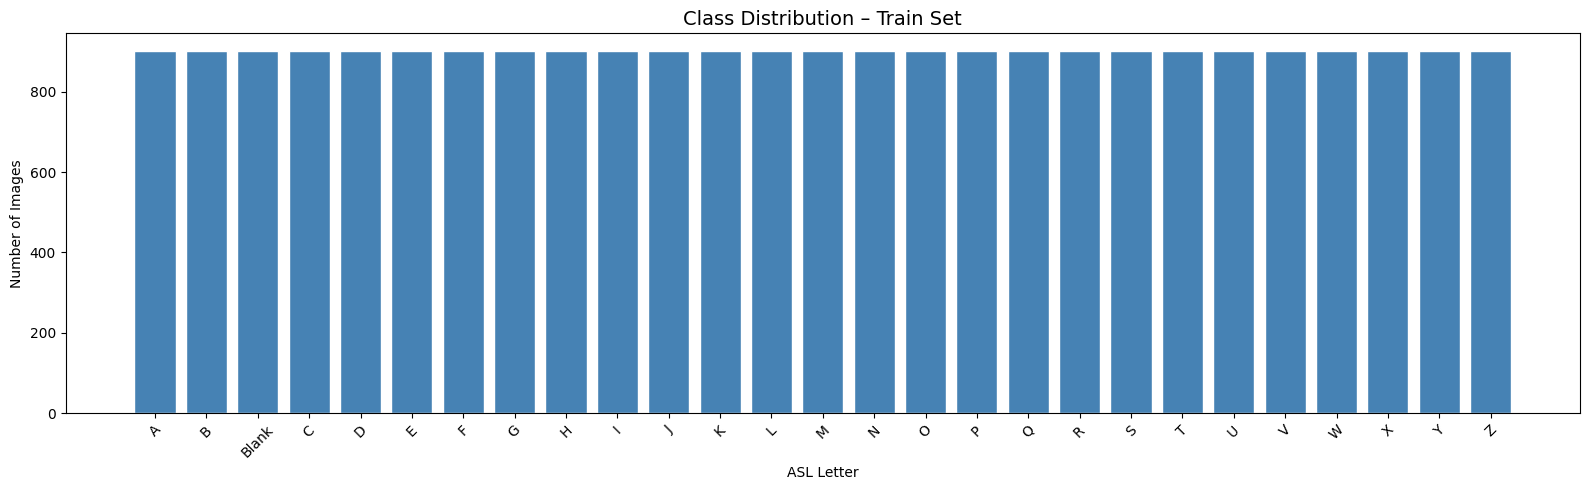

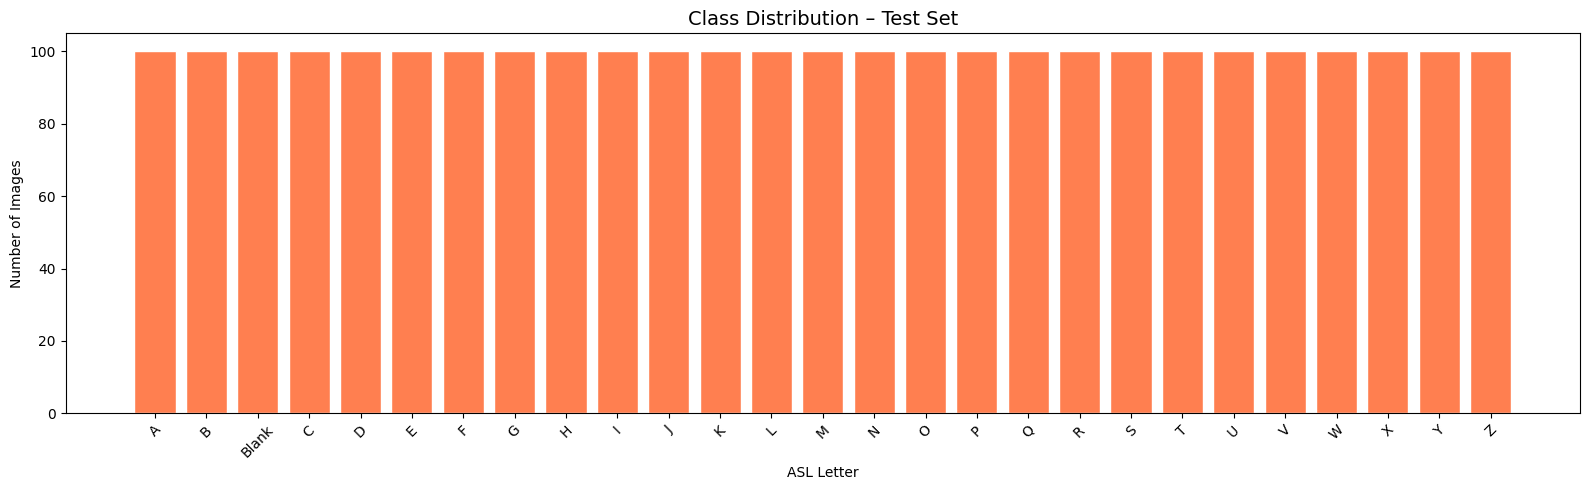

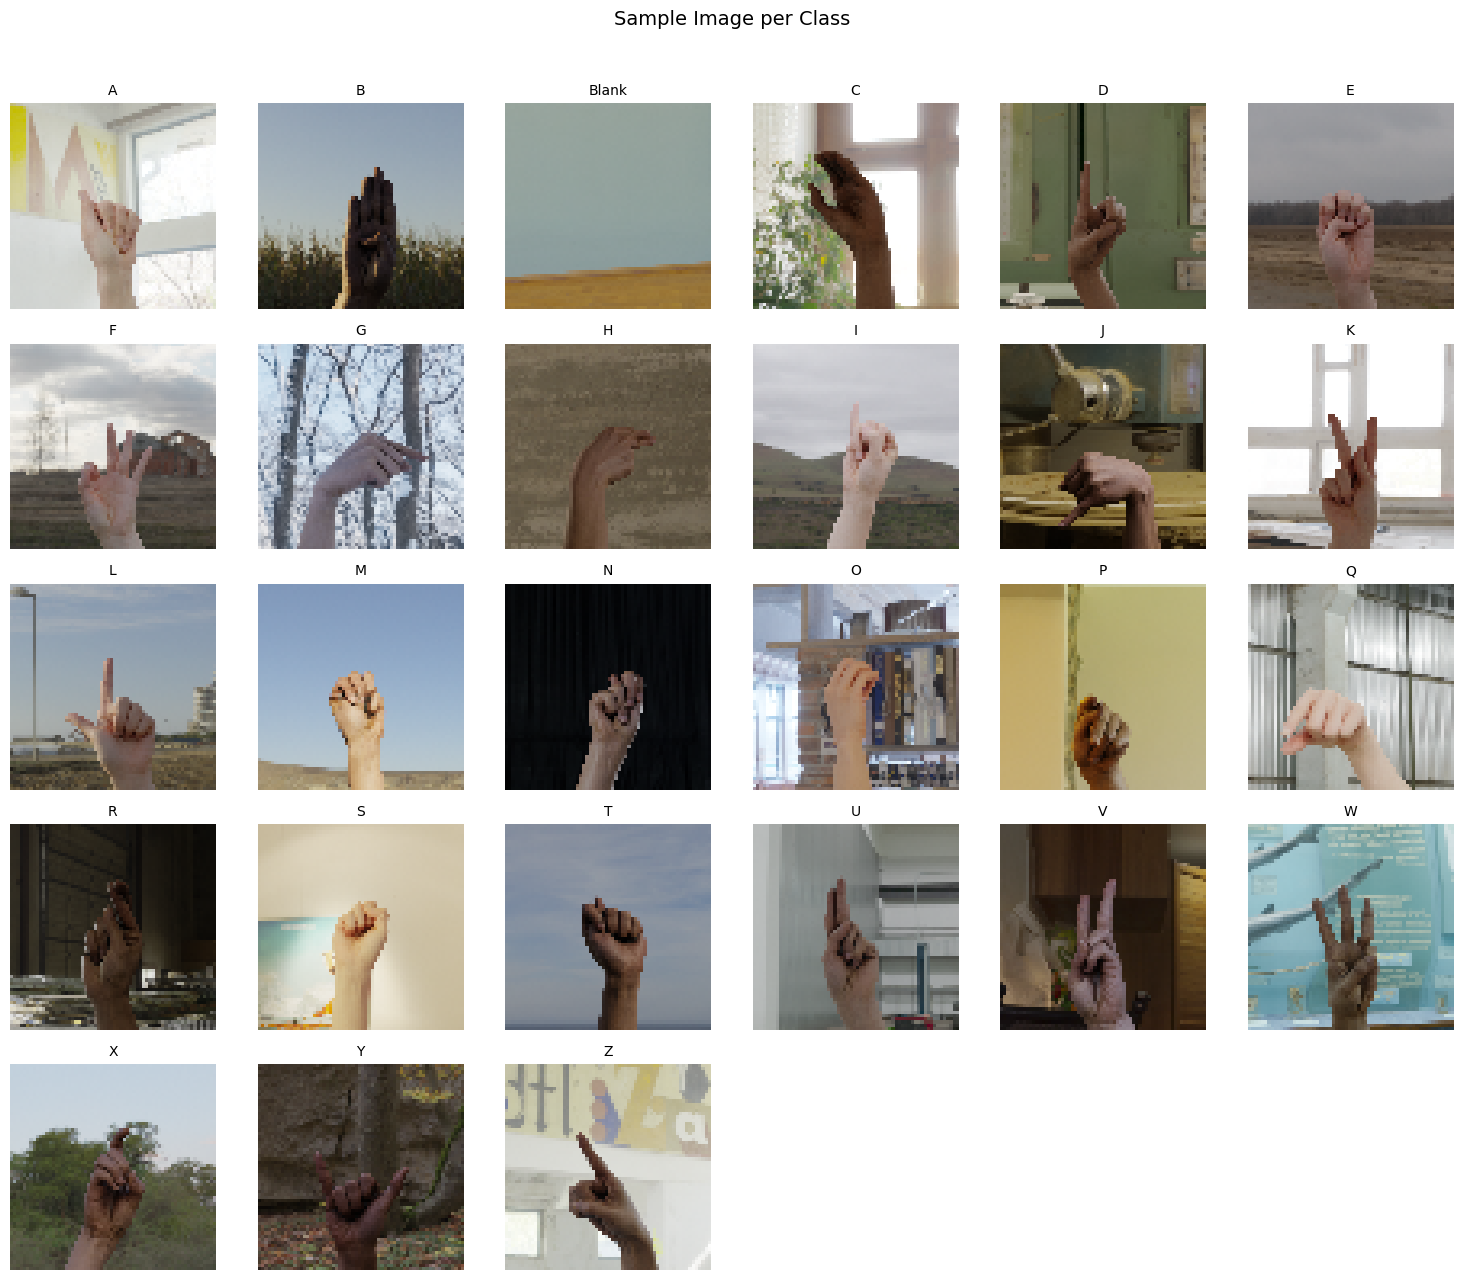

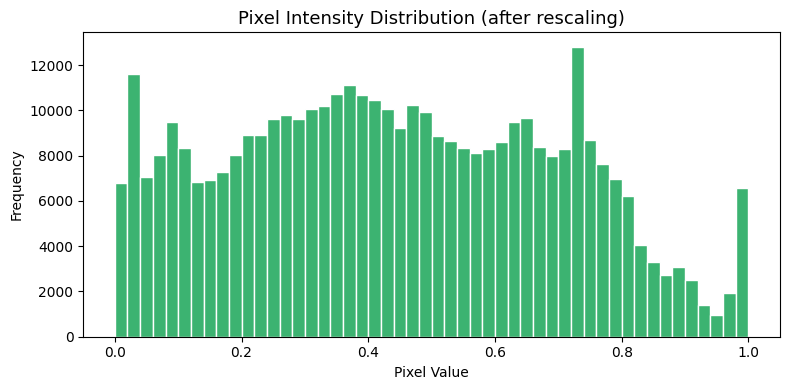

In [2]:
# ── Dataset Overview ──────────────────────────────────────────────────────────
classes      = list(train_gen.class_indices.keys())
num_classes  = len(classes)

# Count images per class in Train and Test directories
train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in classes}
test_counts  = {cls: len(os.listdir(os.path.join(TEST_DIR,  cls))) for cls in classes}

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print(f"Number of classes  : {num_classes}")
print(f"Classes            : {classes}")
print(f"Total train images : {total_train}")
print(f"Total test images  : {total_test}")
print(f"Image size         : {IMG_SIZE}x{IMG_SIZE}")

# ── Class Distribution – Train Set ───────────────────────────────────────────
plt.figure(figsize=(16, 5))
plt.bar(train_counts.keys(), train_counts.values(), color='steelblue', edgecolor='white')
plt.title('Class Distribution – Train Set', fontsize=14)
plt.xlabel('ASL Letter')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Class Distribution – Test Set ────────────────────────────────────────────
plt.figure(figsize=(16, 5))
plt.bar(test_counts.keys(), test_counts.values(), color='coral', edgecolor='white')
plt.title('Class Distribution – Test Set', fontsize=14)
plt.xlabel('ASL Letter')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Sample Images – one per class ────────────────────────────────────────────
cols = 6
rows = int(np.ceil(num_classes / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_dir    = os.path.join(TRAIN_DIR, cls)
    img_file   = os.listdir(cls_dir)[0]
    img_path   = os.path.join(cls_dir, img_file)
    img        = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=10)
    axes[idx].axis('off')

# Hide any unused subplots
for idx in range(num_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Image per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Pixel Intensity Distribution (sample batch) ───────────────────────────────
sample_images, _ = next(train_gen)
plt.figure(figsize=(8, 4))
plt.hist(sample_images.ravel(), bins=50, color='mediumseagreen', edgecolor='white')
plt.title('Pixel Intensity Distribution (after rescaling)', fontsize=13)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Epoch 1/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 366s 593ms/step - accuracy: 0.0818 - loss: 3.5654 - val_accuracy: 0.1990 - val_loss: 2.7899 - learning_rate: 0.0010
Epoch 2/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 285s 469ms/step - accuracy: 0.2101 - loss: 2.5626 - val_accuracy: 0.3418 - val_loss: 2.0500 - learning_rate: 0.0010
Epoch 3/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 290s 477ms/step - accuracy: 0.3234 - loss: 2.0884 - val_accuracy: 0.4033 - val_loss: 1.7953 - learning_rate: 0.0010
Epoch 4/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 301s 495ms/step - accuracy: 0.4448 - loss: 1.6725 - val_accuracy: 0.6465 - val_loss: 1.1275 - learning_rate: 0.0010
Epoch 5/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 302s 497ms/step - accuracy: 0.5464 - loss: 1.3444 - val_accuracy: 0.6132 - val_loss: 1.2987 - learning_rate: 0.0010
Epoch 6/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 301s 495ms/step - accuracy: 0.6605 - loss: 1.0352 - val_accuracy: 0.7792 - val_loss: 0.6597 - learning_rate: 0.0010
Epoch 7/20
608/608 ━━━━━━━━━━━━━━━━━━━━ 289s 476ms/step - accura

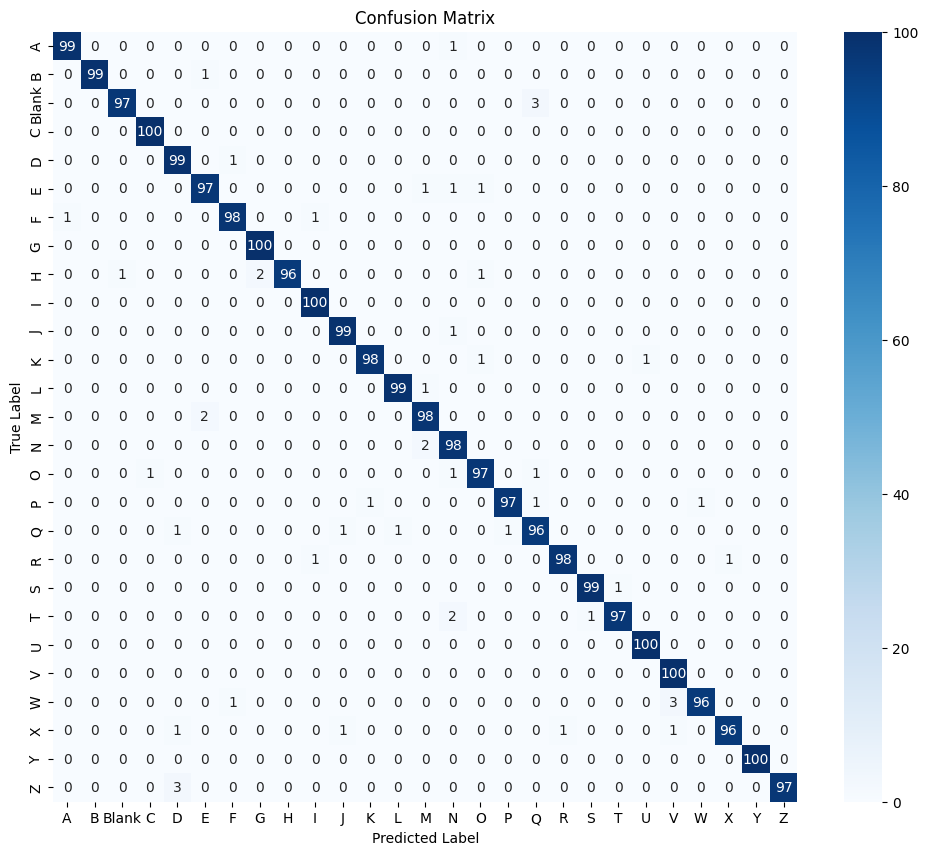


Classification Report:
              precision    recall  f1-score   support

           A       0.99      0.99      0.99       100
           B       1.00      0.99      0.99       100
       Blank       0.99      0.97      0.98       100
           C       0.99      1.00      1.00       100
           D       0.95      0.99      0.97       100
           E       0.97      0.97      0.97       100
           F       0.98      0.98      0.98       100
           G       0.98      1.00      0.99       100
           H       1.00      0.96      0.98       100
           I       0.98      1.00      0.99       100
           J       0.98      0.99      0.99       100
           K       0.99      0.98      0.98       100
           L       0.99      0.99      0.99       100
           M       0.96      0.98      0.97       100
           N       0.94      0.98      0.96       100
           O       0.97      0.97      0.97       100
           P       0.99      0.97      0.98       100
   

In [4]:
# 3. CNN MODEL ARCHITECTURE
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),  # Prevents overfitting by randomly dropping neurons
    Dense(len(train_gen.class_indices), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. TRAINING WITH CALLBACKS
# EarlyStopping ends training if the model stops improving to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

# 5. EVALUATION & METRICS
print("\n--- Evaluation on Test Set ---")
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Predictions for Confusion Matrix
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
classes = list(test_gen.class_indices.keys())

# Confusion Matrix Heatmap
cm = confusion_matrix(test_gen.classes, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Detailed Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(test_gen.classes, y_pred, target_names=classes))
